# Manual Pipeline 2
- In this notebook, I will refactor the manual_pipeline1 processing into a single function.
- I will have an option for autopower or n_points as part of the function.
- Add function that tests for closeness between selected peaks:
    - Consider the LSP resolution.
- Afterwards cluster peaks in the same ranges and choose the strongest like in the priors analysis.

In [4]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
from scipy.optimize import curve_fit


# Individual stars
raw_HD81809 = pd.read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD160346 = pd.read_csv(r"../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD201091 =pd.read_csv(r"../Data/benchmark/HD201091_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)

def prepare_df(data, add_prefix=False):
    data = data.copy()
    data.columns = ["JD", "sind"]
    if add_prefix:
        data['JD'] = data['JD'] + 2400000.0
    time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
    data["year"] = time_obj.jyear
    data["day"] = time_obj.jd
    data['datetime'] = time_obj.to_datetime(timezone=None)
    data = data.set_index('datetime')
    return data


# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.8, valid_split=0.19):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()


data_HD81809 = prepare_df(raw_HD81809)
data_HD160346 = prepare_df(raw_HD160346)
data_HD201091 = prepare_df(raw_HD201091)

train_HD81809,  valid_HD81809,  test_HD81809  = split_df(data_HD81809)
train_HD160346, valid_HD160346, test_HD160346 = split_df(data_HD160346)
train_HD201091, valid_HD201091, test_HD201091 = split_df(data_HD201091)




C:\Users\Joey\AppData\Local\Temp\ipykernel_12212\595774739.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD81809 = pd.read_csv(r"../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_12212\595774739.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD160346 = pd.read_csv(r"../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_12212\595774739.py:17: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separat

In [5]:
def check_aliases(freq, accepted_freqs, tol = 0.05):
    '''
    Check if a single period is an alias.
    If it is an alias we can skip it and use the next period as dominant.
    Aliases are not subtracted: they are noise.
    If True, signal is not an alias so set it be added.
    '''
    accepted_periods = 1/np.array(accepted_freqs)
    for p in accepted_periods:
        for mult in [0.25, 1/3, 0.5, 1, 2, 3, 4]:
            pmult_freq = 1/(p*mult)
            delta = np.abs((freq - pmult_freq)/freq)
            if delta < tol: # The signal is an alias
                return False, p, mult, delta
    return True, None, None, None

def check_windows(freq, tol = 0.05):
    '''
    Checks if a signal looks suspiciously like a window function.
    If True, signal is not a window as defined.
    '''
    year = 365.25
    month = year /12
    week = 7
    windows = [year, year/2, year/3, year/4, month, 2*month, week, 2* week, 3 * week, 29.5] #29.5 is lunar
    for window in windows:
        window_freq = 1/np.array(window)
        delta = np.abs((freq-window_freq)/freq)
        if delta < tol: # Then we classify the signal as a window function
            return False, window, delta
    return True, None, None

# Helpers for performing the SNR checks
def gaussian(t, A, mu, std, c):
    return A * np.exp(-0.5 * ((t - mu) / std)**2) + c

def find_snr(powers, freqs, peak_freq, peak_idx, peak_height, window = 150):
    '''
    Fits a Gaussian around a peak, subtracts that peak Gaussian, and then compares it to the remaining residual noise.
    '''
    # Define a window around the peak to which to fit a Gaussian
    n = len(powers)
    left  = max(0, peak_idx - window)
    right = min(n, peak_idx + window + 1)
    window_freqs = freqs[left:right]
    window_powers = powers[left:right]
    minf = min(window_freqs)
    maxf = max(window_freqs)

    # Define initial guesses for the fit
    A0 = peak_height
    mu0 = peak_freq
    std0 = mu0 * 0.1 #FWHM is a bit overkill
    c0 = np.median(window_powers)
    p0 = [A0, mu0, std0, c0]

    # Try the curve fit
    try:
        popt, _ = curve_fit(gaussian, window_freqs, window_powers,
                        p0 = p0,
                        bounds = ([0, minf, 0, 0], [np.inf, maxf, np.inf, np.inf]))
        resid_lsp = window_powers - gaussian(window_freqs, *popt)
        noise_std = np.std(resid_lsp)
        snr = A0 / noise_std
        return snr, popt, resid_lsp
    except (RuntimeError, ValueError):
        continuum = np.median(window_powers)
        noise = np.std(window_powers)
        return (A0 - continuum) / noise, None, None


def build_design_matrix(t, accepted_freqs):
    """
    Constructs the design matrix for a linear least-squares fit
    of multiple sine/cosine pairs (plus a constant offset).
    """
    # Start with a column of ones for the offset (DC component)
    cols = [np.ones(len(t))]
    
    for f in accepted_freqs:
        # Math: 2 * pi * frequency * time
        # This is equivalent to (2 * pi * t) / period
        cols.append(np.cos(2 * np.pi * f * t))
        cols.append(np.sin(2 * np.pi * f * t))
        
    return np.column_stack(cols)

def simultaneous_fit(t, y, accepted_freqs):
    """
    Fits all identified frequencies simultaneously and returns 
    the residuals for the next iteration of the LSP.
    """
    if not accepted_freqs:
        # If no frequencies yet, residuals are just the original data
        return y, np.array([np.mean(y)])

    # 1. Build the matrix
    X = build_design_matrix(t, accepted_freqs)
    
    # 2. Solve the linear system: X * params = y
    # np.linalg.lstsq is robust for this kind of overdetermined system
    params, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    
    # 3. Calculate the model and the residuals
    fitted_model = X @ params
    residuals = y - fitted_model
    
    return residuals, params

def set_period_axes(ax, ylabel='Normalised Power'):
    ax2 = ax.secondary_xaxis('top', functions=(lambda d: d / 365.25, lambda y: y * 365.25))
    ax2.set_xlabel('Period (years)')
    ax.set_xlabel('Period (days)')
    ax.set_ylabel(ylabel)

In [10]:

def fit_peaks(df,
            manual_freq = 'linear', period_range = [0.1, 100*365], n_periods = 100000, 
            FAPs = [10,5,1,0.1], key_FAP_idx = -1, 
            threshold = 5,
            plot = True, verbose = True):
    '''
    Iteratively finds the peaks of the LSP.
    This will be used in the prior selsection process.
    Finds one peak then checks if it is an alias or a window.
    Also checks if it is too similar to a previous peak for the LSP to have resolved.
    If that peak also satiesfies an SNR threshold, add it to an accepted periods list.

    df is the dataframe being processed (training set)
    manual_freq True means the period_range and n_periods defines the set of periods calculated.
    Period_range is in days

    Returns a list of accepted periods.
    '''
    accepted_peak_freqs = [] # We will work in frequency space for the analysis other than for the plotting. It is easier for the SNR fitting.
    accepted_peak_heights = [] # The concomitant power heights

    if manual_freq == 'linear':
        min_period = period_range[0]
        max_period = period_range[1]
        periods = np.linspace(min_period, max_period, n_periods)
        freqs = 1 / periods
    if manual_freq == 'log':
        min_period = period_range[0]
        max_period = period_range[1]
        periods = np.logspace(np.log10(min_period), np.log10(max_period), n_periods)
        freqs = 1 / periods

    resids = [df['sind']]
    iter_powers = [] # Add the LSPs here
    iter_params = [] # Parameters of the simultaneous fit
    iter_peak_freqs = [] # the full list of peaks found at each stage
    iter_invFAPs = [] # the list of powers corresponding to the FAPs
    iter_popts = [] # popts of the Gaussian fit
    iter_SNRs = []

    i = 0 # What index in resids we are presently processing
    t = df['day'] # Fixed time axis for al
    data_timeframe = t[-1] - t[0]
    max_detectable_period = 3 * data_timeframe #  2 sinusoids typically required to fit reliably
    print(max_detectable_period)

    # Now calculate the FAPs
    FAPs = np.array(FAPs)/100

    while True:
        # Take the LSP : powers for the freqs
        ls = LombScargle(t, resids[i])
        if manual_freq is None: # Use autopower
            freqs, powers = ls.autopower()
            periods = 1/freqs
        else:
            powers = ls.power(freqs)

        power_invFAPs = ls.false_alarm_level(FAPs, method = 'bootstrap') 
        key_FAP = float(power_invFAPs[key_FAP_idx])
        # Identify FAPs above the key FAP
        peak_idxs, properties = find_peaks(powers, height=key_FAP) # peaks is an array of the indices of the input arrays with the peaks
        peak_freqs = freqs[peak_idxs]
        peak_heights = properties['peak_heights']

        # Break if none
        if len(peak_freqs) == 0:
            break

        # Sort identified peaks by height
        sort_idx = np.argsort(peak_heights)[::-1]
        peak_freqs = peak_freqs[sort_idx]
        peak_heights = peak_heights[sort_idx] 
        peak_idxs = peak_idxs[sort_idx]

        found = False
        # Loop through peaks until one satisfies conditions or the end is reached
        for peak_freq, peak_height, peak_idx in zip(peak_freqs, peak_heights, peak_idxs):

            # Check if less than max_period
            if 1/peak_freq > max_detectable_period:
                print(f"Peak at period {1/peak_freq:.2f} days is greater than maximum detectable period of {max_detectable_period} days.")
            # Less than maxperiod check if alias
            else:
                alias_cond, p, mult, delta = check_aliases(freq = peak_freq, accepted_freqs= accepted_peak_freqs)
                if alias_cond == False: # This is an alias; skip freq
                    print(f"Peak at period {1/peak_freq:.2f} was identified to be an alias of {p:.2f} days at mult {mult:.2f} by tolerance {delta:.2f}.")

                else: # Not an alias; now check window
                    window_cond, window, delta = check_windows(freq = peak_freq)
                    if window_cond == False: # This is a window function; skip freq
                        print(f"Peak at period {1/peak_freq:.2f} was identified to be a window of {window:.2f} days by tolerance {delta:.2f}.")
                    
                    else: # Not a window; now check SNR
                        snr, popt, resid_lsr =  find_snr(powers, freqs, peak_freq, peak_idx, peak_height, window = 150)
                        if popt is None:
                            print("SNR failed to fit Gaussian. Fell back to height vs average.")

                        if snr > threshold: # All checks passed. Append
                            accepted_peak_freqs.append(peak_freq) # Freq, height
                            accepted_peak_heights.append(peak_height)
                            found = True # indicates that we have added a frequency this time
                            print(f"In iteration {i}, period at {1/peak_freq:.2f} days was accepted.")
                            break # stops searching freqs
                        
                        else: # Go to nest frequency
                            print(f"Period of {1/peak_freq:.2f} failed SNR > {threshold} with SNR of {snr}")

        # if we have not found a frequency, this means that we have reached the FAP limit
        if found == False:
            print(f"Iteration {i} did not find a frequency: terminating loop.")
            break

        else: # freq found now do the refitting for the next loop round
            resid, params = simultaneous_fit(df['day'], df['sind'], accepted_peak_freqs)
            resids.append(resid)
            iter_powers.append(powers) # The LSPs for plotting
            iter_params.append(params)
            iter_peak_freqs.append(peak_freqs)
            iter_invFAPs.append(power_invFAPs)
            iter_SNRs.append(snr)
            if popt is None:
                iter_popts.append(None)
            else:
                iter_popts.append(popt)
            i += 1 # Now the cycle repeats with the new set of resids

    periods = 1/freqs

    # Now we have a list of freqs: plot and return
    n_iter = len(resids)-1 # how many iterations we completed 
    if plot:
        fig, ax = plt.subplots(n_iter, 3, figsize=(10*3, 7*n_iter))
        ax = np.atleast_2d(ax)

        col_titles = ['LSP', 'Residual LSP', 'Fit & Residuals']
        for col, title in enumerate(col_titles):
            ax[0][col].set_title(title, fontsize=14, fontweight='bold')

        for row in range(n_iter):
            # ---- Col 0: LSP ----
            ax[row][0].set_xscale('log')
            ax[row][0].plot(periods, iter_powers[row], label = 'LS Periodogram')
            set_period_axes(ax[row][0])

            # plotting the FAPs
            fap_colors = ['#2ecc71', '#a8d44a', '#e67e22', '#e74c3c']
            power_invFAPs = iter_invFAPs[row]
            for power_invFAP, fap_color, fap_level in zip(power_invFAPs, fap_colors, FAPs):
                ax[row][0].axhline(power_invFAP, color=fap_color, label=f'FAP {fap_level * 100} %', lw=0.4)

            peak_periods_row = 1 / np.array(iter_peak_freqs[row])
            for j,peak_period in enumerate(peak_periods_row):
                ax[row][0].axvline(peak_period, color='purple', lw=0.4,
                                   label='Peak' if j == 0 else None)

            popt = iter_popts[row]
            if popt is not None:
                ax[row][0].plot(periods, gaussian(freqs, *popt), color='lime', label = "Gaussian fit")
            
            ax[row][0].legend()

            # ---- Col 1: Residual LSP (Gaussian subtracted) ----
            ax[row][1].set_xscale('log')
            ax[row][1].sharey(ax[row][0])
            ax[row][1].sharex(ax[row][0])
            set_period_axes(ax[row][1])
            if popt is not None:
                ax[row][1].plot(periods, iter_powers[row] - gaussian(freqs, *popt))

            # ---- Col 2: Previous residual, simultaneous fit, current residual vs time ----
            ax_t = ax[row][2]
            prev_resid = np.array(resids[row])
            curr_resid = np.array(resids[row + 1])
            fit_component = prev_resid - curr_resid  # sinusoidal component added this iteration

            t_vals = np.array(t)
            sort_idx = np.argsort(t_vals)

            ax_t.scatter(t_vals, prev_resid, s=2, color='orange',     alpha=0.5, label='Previous residual', zorder=1)
            ax_t.scatter(t_vals, curr_resid, s=2, color='green', alpha=0.5, label='Residual',          zorder=2)
            ax_t.plot(t_vals[sort_idx], fit_component[sort_idx], color='blue', lw=1, label='Simultaneous fit', zorder=3)

            ax_t.set_xlabel('Time (days)')
            ax_t.set_ylabel('S-index')
            ax_t.legend(fontsize=8, markerscale=3)

        plt.tight_layout()
        plt.show()
    
    accepted_peak_periods = 1/np.array(accepted_peak_freqs)
    if verbose:
        print("Accepted periods and their heights")
        table = PrettyTable(["Days", "Years", "Height", "SNR"])
        for accepted_peak_period, accepted_peak_height, snr in zip(accepted_peak_periods, accepted_peak_heights, iter_SNRs):
            table.add_row([f"{accepted_peak_period:.2f}", f"{accepted_peak_period/365:.2f}", f"{accepted_peak_height:.2f}", f"{snr:.2f}"])
        print(table)

    return accepted_peak_periods, accepted_peak_heights


---
## Verification
- Now that we have some code to do the analysis that is verified against the first star, now we can run it for all three and compare to the literature values.

HD81809

C:\Users\Joey\AppData\Local\Temp\ipykernel_12212\1220180567.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 2991.66 days was accepted.
In iteration 1, period at 40.25 days was accepted.
In iteration 2, period at 44.27 days was accepted.
In iteration 3, period at 1813.07 days was accepted.
Peak at period 41.71 was identified to be an alias of 40.25 days at mult 1.00 by tolerance 0.04.
Peak at period 7119.84 was identified to be an alias of 1813.07 days at mult 4.00 by tolerance 0.02.
In iteration 4, period at 37.33 days was accepted.
In iteration 5, period at 6847.55 days was accepted.
Peak at period 42.44 was identified to be an alias of 44.27 days at mult 1.00 by tolerance 0.04.
Peak at period 21.27 was identified to be an alias of 44.27 days at mult 0.50 by tolerance 0.04.
Peak at period 38.06 was identified to be an alias of 37.33 days at mult 1.00 by tolerance 0.02.
Period of 47.19 failed SNR > 5 with SNR of 4.633401992630882
Iteration 6 did not find a frequency: terminating loop.


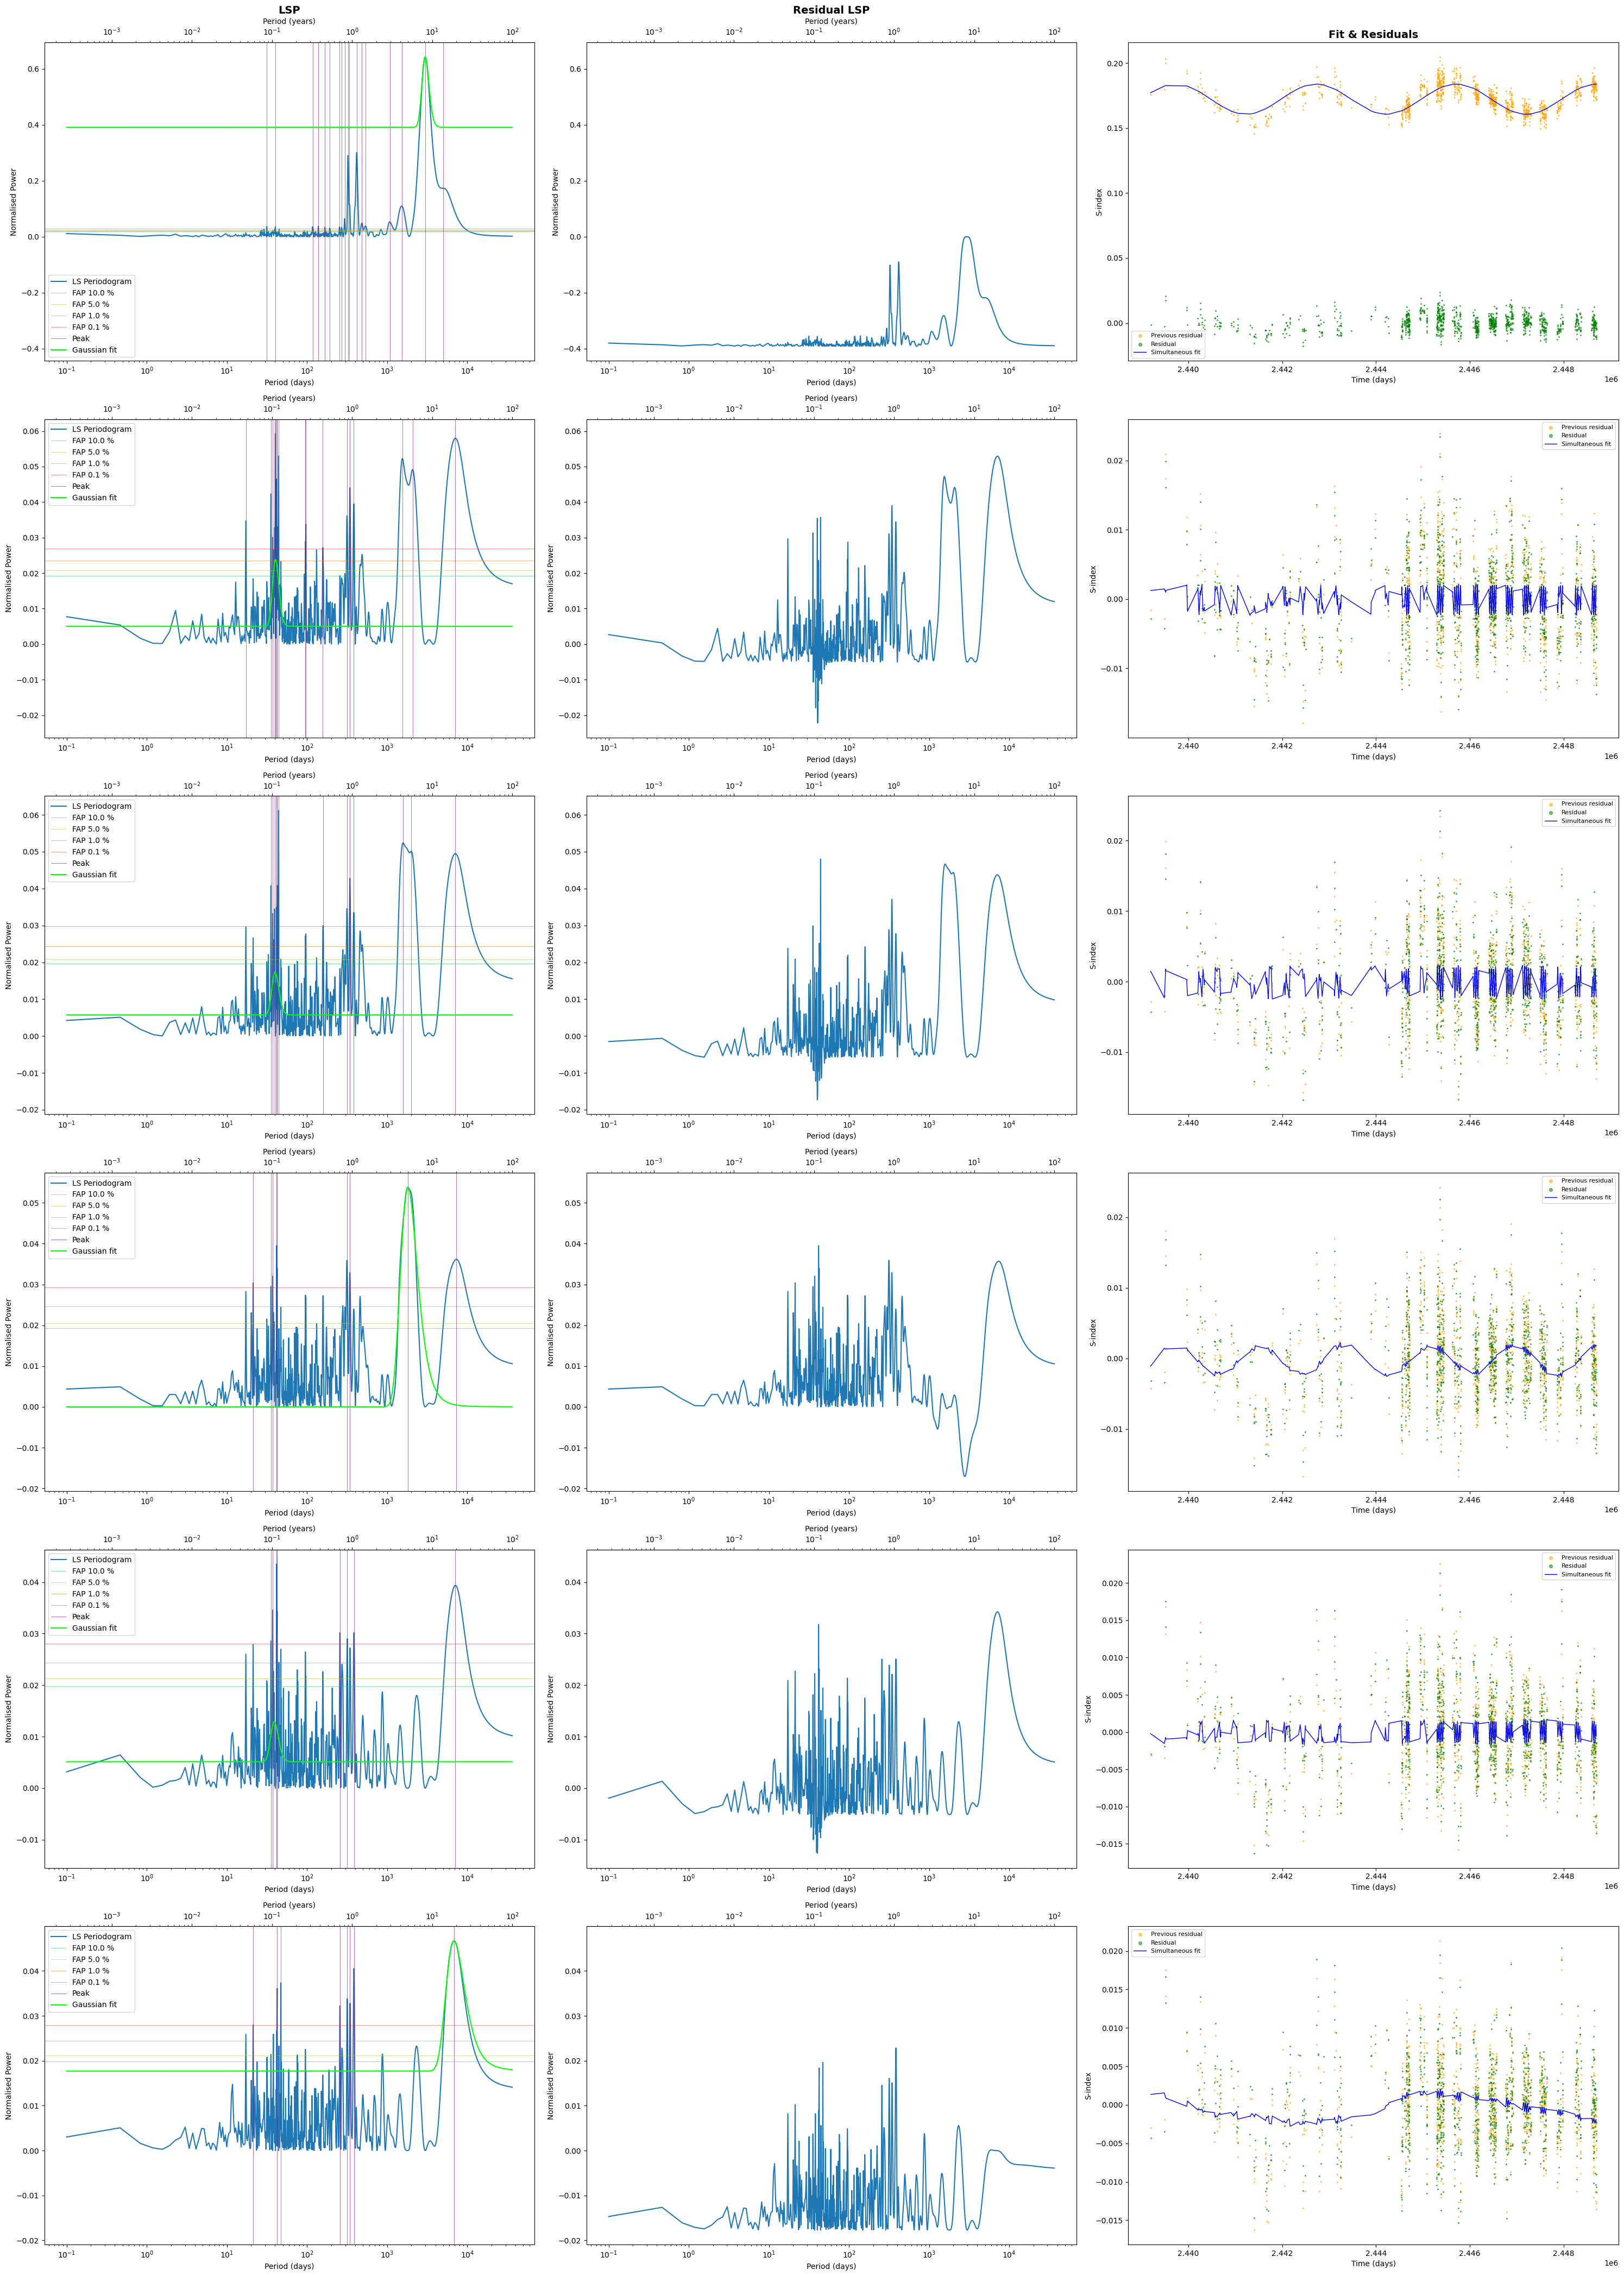

Accepted periods and their heights
+---------+-------+--------+------------+
|   Days  | Years | Height |    SNR     |
+---------+-------+--------+------------+
| 2991.66 |  8.20 |  0.64  |  76181.21  |
|  40.25  |  0.11 |  0.06  |    8.76    |
|  44.27  |  0.12 |  0.06  |    8.00    |
| 1813.07 |  4.97 |  0.05  |  3539.12   |
|  37.33  |  0.10 |  0.03  |    5.32    |
| 6847.55 | 18.76 |  0.05  | 3575428.99 |
+---------+-------+--------+------------+


In [7]:
peaks_HD81809, heights_HD81809 = fit_peaks(train_HD81809)

HD160346

C:\Users\Joey\AppData\Local\Temp\ipykernel_12212\3629258397.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


25379.70644999994
In iteration 0, period at 2505.48 days was accepted.
In iteration 1, period at 23064.62 days was accepted.
In iteration 2, period at 468.40 days was accepted.
Peak at period 1341.12 was identified to be an alias of 468.40 days at mult 3.00 by tolerance 0.05.
In iteration 3, period at 1082.70 days was accepted.
Peak at period 153.40 was identified to be an alias of 468.40 days at mult 0.33 by tolerance 0.02.
In iteration 4, period at 35.14 days was accepted.
Peak at period 153.40 was identified to be an alias of 468.40 days at mult 0.33 by tolerance 0.02.
Peak at period 107.78 was identified to be an alias of 35.14 days at mult 3.00 by tolerance 0.02.
Period of 405.62 failed SNR > 5 with SNR of 4.931436498095705
In iteration 5, period at 96.10 days was accepted.
In iteration 6, period at 404.89 days was accepted.
Peak at period 153.40 was identified to be an alias of 468.40 days at mult 0.33 by tolerance 0.02.
Peak at period 107.78 was identified to be an alias of 35.1

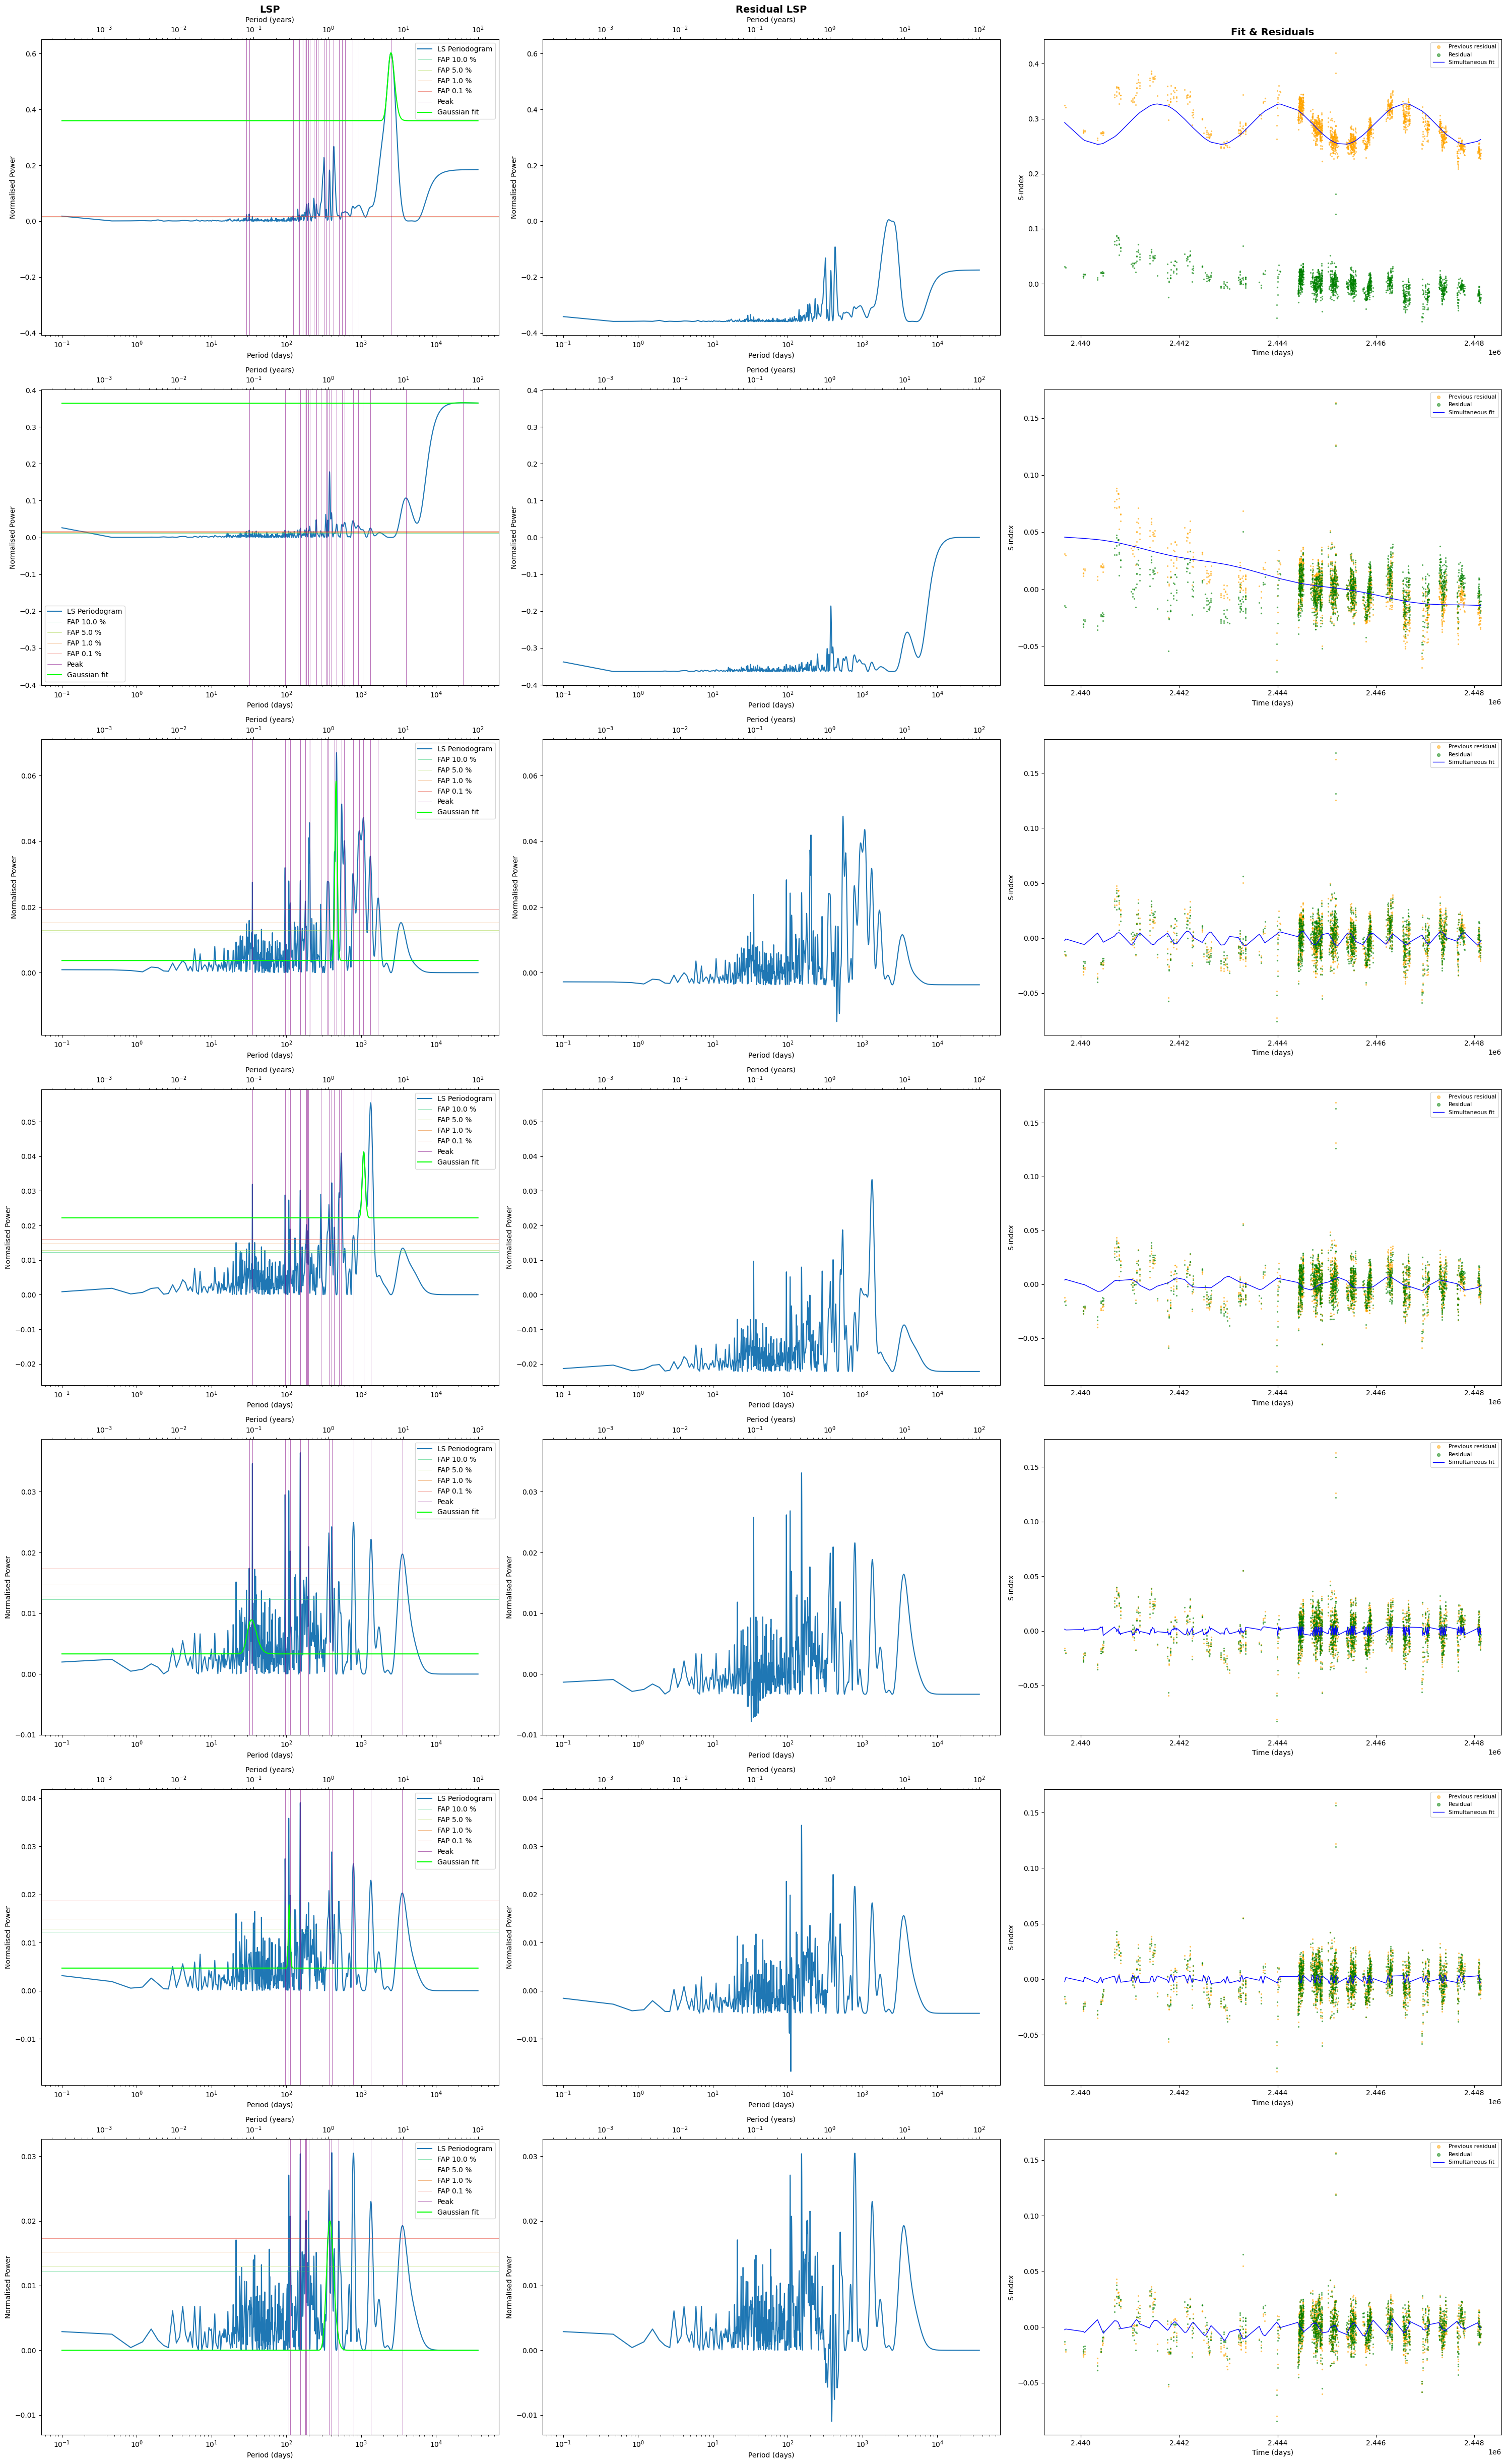

Accepted periods and their heights
+----------+-------+--------+----------------+
|   Days   | Years | Height |      SNR       |
+----------+-------+--------+----------------+
| 2505.48  |  6.86 |  0.60  |    20391.25    |
| 23064.62 | 63.19 |  0.37  | 21331058221.45 |
|  468.40  |  1.28 |  0.07  |      7.99      |
| 1082.70  |  2.97 |  0.04  |     454.11     |
|  35.14   |  0.10 |  0.03  |      9.69      |
|  96.10   |  0.26 |  0.03  |      5.61      |
|  404.89  |  1.11 |  0.03  |      5.18      |
+----------+-------+--------+----------------+


In [11]:
peaks_HD160346, heights_HD160346 = fit_peaks(train_HD160346)

HD201091 

C:\Users\Joey\AppData\Local\Temp\ipykernel_12212\3629258397.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


24515.431799999904
In iteration 0, period at 2730.68 days was accepted.
In iteration 1, period at 12043.36 days was accepted.
Peak at period 1366.67 was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.00.
In iteration 2, period at 505.26 days was accepted.
Peak at period 1377.25 was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.01.
In iteration 3, period at 290.64 days was accepted.
In iteration 4, period at 36.97 days was accepted.
Peak at period 2070.03 was identified to be an alias of 505.26 days at mult 4.00 by tolerance 0.02.
In iteration 5, period at 443.94 days was accepted.
Peak at period 36.60 was identified to be an alias of 36.97 days at mult 1.00 by tolerance 0.01.
In iteration 6, period at 39.89 days was accepted.
In iteration 7, period at 33.32 days was accepted.
Peak at period 156.32 was identified to be an alias of 39.89 days at mult 4.00 by tolerance 0.02.
Peak at period 252.68 was identified to be an alias of 505.26 days a

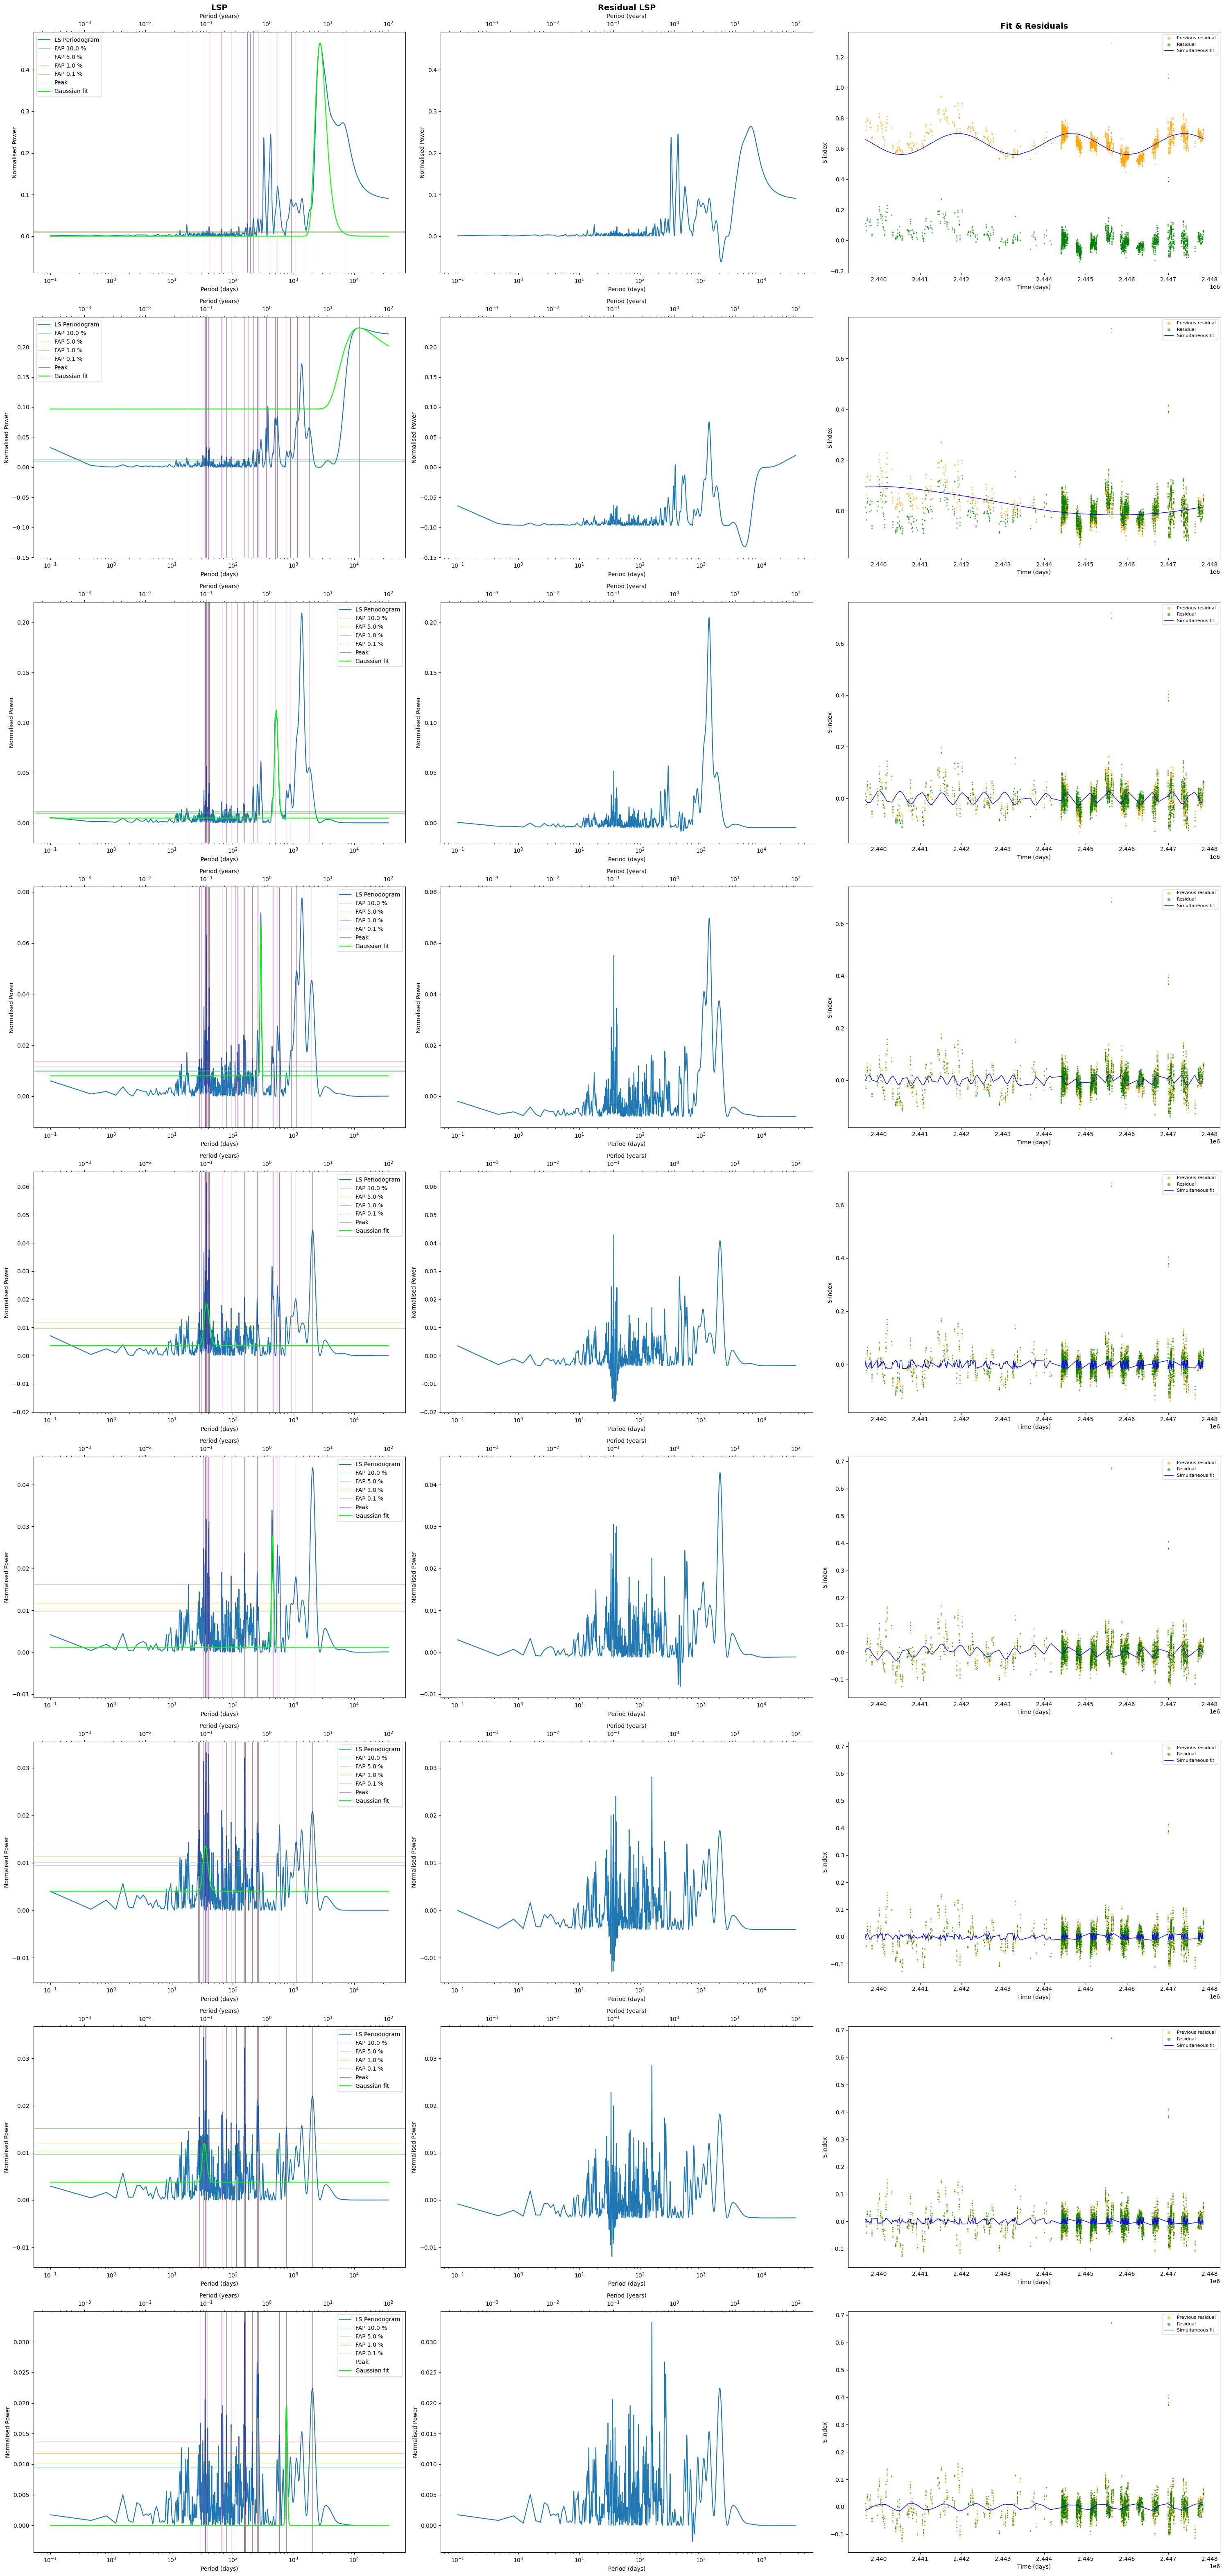

Accepted periods and their heights
+----------+-------+--------+--------------+
|   Days   | Years | Height |     SNR      |
+----------+-------+--------+--------------+
| 2730.68  |  7.48 |  0.46  |   23570.79   |
| 12043.36 | 33.00 |  0.23  | 117241745.13 |
|  505.26  |  1.38 |  0.11  |    18.65     |
|  290.64  |  0.80 |  0.07  |    10.01     |
|  36.97   |  0.10 |  0.06  |     9.87     |
|  443.94  |  1.22 |  0.03  |     7.53     |
|  39.89   |  0.11 |  0.03  |     6.19     |
|  33.32   |  0.09 |  0.03  |     7.37     |
|  762.59  |  2.09 |  0.02  |    13.95     |
+----------+-------+--------+--------------+


In [12]:
peaks_HD201091, heights_HD201091 = fit_peaks(train_HD201091)

# THESE ALL MATCH THE LITERATURE!!!!!
